# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
import pandas as pd

In [2]:
train_fname = 'tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)

In [3]:
raw_df[:5]

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [5]:
df = raw_df.dropna().reset_index(drop=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27480 entries, 0 to 27479
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [7]:
df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


Для подальшої роботи значення цільової колонки треба замінити з текстового на числове

In [8]:
sentiment_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['sentiment_encoded'] = df['sentiment'].map(sentiment_mapping)

Найбільша кількість нейтральних міток. Розділення залишку на позитивні та негативні за кількістю близькі

In [9]:
df['text_len'] = df['text'].str.len()


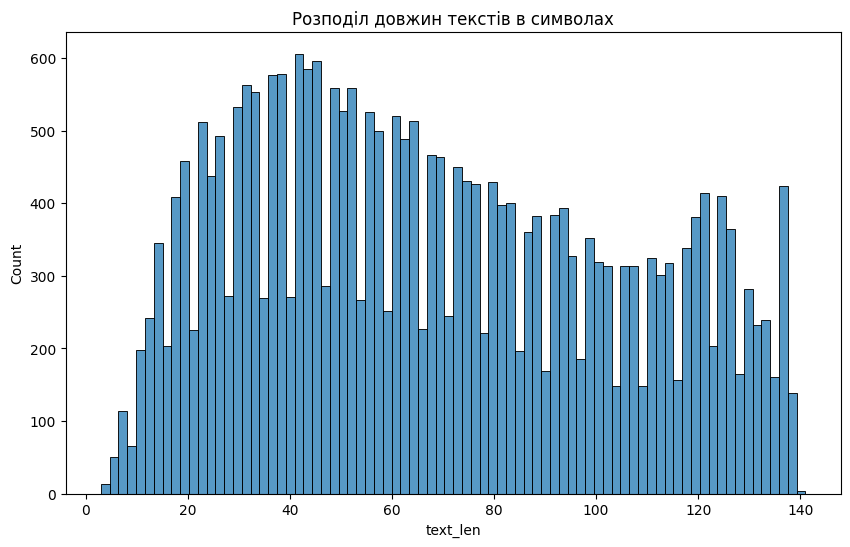

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['text_len'], bins=80)
plt.title('Розподіл довжин текстів в символах')
plt.show()


Відповідно розподілу найбільше постів з кількістю символів 30-50 символів.
Найбільша кількість символів - 140 (яких дуже мало), більше немає мабуть ця кількість є обеженням.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [11]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import string
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
stemmer = SnowballStemmer(language='english')
english_stopwords = set(stopwords.words('english'))

In [14]:
def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())

    processed = [
        stemmer.stem(word)
        for word in tokens
        if word not in english_stopwords and word not in string.punctuation
    ]

    return " ".join(processed)

df['preprocessed_text'] = df['text'].apply(preprocess_text)
vectorizer = CountVectorizer(max_features=5000)
X_ = vectorizer.fit_transform(df['preprocessed_text'])

X_.shape

(27480, 5000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_, df.sentiment_encoded,
                                                                        test_size=0.3, random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
MAX_ITER = 500

In [19]:
lr_model = LogisticRegression(max_iter=MAX_ITER, solver='sag')

In [20]:
lr_model.fit(X_train_bow, y_train)

LogisticRegression(max_iter=500, solver='sag')

In [21]:
train_preds = lr_model.predict(X_train_bow)
test_preds = lr_model.predict(X_test_bow)

In [22]:
from sklearn.metrics import f1_score

In [23]:
f1_train =f1_score(y_train, train_preds, average='macro')
f1_test =f1_score(y_test, test_preds, average='macro')
f1_train, f1_test

(0.8269862562581981, 0.6779165831224038)

In [24]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(max_depth=20, random_state=42)
tree_model.fit(X_train_bow, y_train)

tree_test_preds = tree_model.predict(X_test_bow)
f1_tree_test = f1_score(y_test, tree_test_preds, average='macro')
f1_tree_test

0.58929656382134

З 2 моделей Logistic Regression та  Decision Tree найкращий результат дала на тестових даних Logistic Regression так як показник f1 становить 67,8% проти 58,9% моделі Decision Tree.

Відповідно результат Logistic Regression є гарними так як ми маємо 3 класи при передбачені, а не 2.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [25]:
words_in_vocabulary = list(vectorizer.get_feature_names_out())


In [26]:
print(f"Довжина словника: {len(words_in_vocabulary)}")
print(f"Форма коефіцієнтів моделі: {lr_model.coef_.shape}")

Довжина словника: 5000
Форма коефіцієнтів моделі: (3, 5000)


In [27]:
neg_importance = pd.Series(lr_model.coef_[0], index=words_in_vocabulary).sort_values(ascending=False)
pos_importance = pd.Series(lr_model.coef_[2], index=words_in_vocabulary).sort_values(ascending=False)

In [28]:
neg_importance[:10]

,0
sad,2.561319
suck,2.452287
bore,2.375074
sorri,2.307184
hate,2.172928
miss,2.114913
disappoint,2.029707
fail,2.009578
stupid,1.980140
shame,1.944122


In [31]:
pos_importance[:10]

,0
awesom,2.780073
cute,2.512915
thank,2.465419
love,2.242330
amaz,2.135280
congrat,2.105354
great,2.074345
enjoy,2.072471
nice,2.067405
congratul,2.045087


Наведений перелік слів які є в негативних текстах зрозумілий такі як ненависть, сум, сором та інші.

У проти вагу слова яки є позиивними індикаторами по тектсу, милий, любов, насолада та інші

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['preprocessed_text'])
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, df.sentiment_encoded, test_size=0.3, random_state=42
)


lr_tfidf = LogisticRegression(max_iter=1000, solver='sag')
lr_tfidf.fit(X_train_tfidf, y_train)
tfidf_preds = lr_tfidf.predict(X_test_tfidf)
f1_test_tfidf = f1_score(y_test, tfidf_preds, average='macro')
f1_test_tfidf

0.6802485278321008

Результат векторизації текстів з векторизатором TfidfVectorizer має майже таких же результата як і Bag of Words з Logistic Regression. Покращення становить 0,02%

In [34]:
tfidf_words = list(tfidf_vectorizer.get_feature_names_out())
neg_importance_tfidf = pd.Series(lr_tfidf.coef_[0], index=tfidf_words).sort_values(ascending=False)
pos_importance_tfidf = pd.Series(lr_tfidf.coef_[2], index=tfidf_words).sort_values(ascending=False)

In [35]:
neg_importance_tfidf[:10]

,0
sad,5.016098
miss,4.971248
sorri,4.393111
suck,4.321634
hate,4.101548
bore,3.892162
fail,3.465947
stupid,3.367749
sick,3.312019
poor,3.205123


In [36]:
pos_importance_tfidf[:10]

,0
love,6.063562
thank,5.565506
awesom,4.943499
great,4.743871
nice,4.394969
happi,4.360690
good,4.232303
hope,4.038147
enjoy,3.680743
amaz,3.668365


Токени які впливають на результат при тренування  класифікатора схожі на попередні але але мають трохи інші оцінки і розставлені в іншому порядку, але зміст залишився той самий.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [43]:
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

In [44]:
test_df['prediction'] = lr_tfidf.predict(X_test_tfidf)

In [39]:
from sklearn.metrics import confusion_matrix

In [45]:
confusion_matrix(test_df.sentiment_encoded, test_df.prediction)

array([[1333,  870,  153],
       [ 427, 2517,  399],
       [  97,  675, 1773]])

'negative': 0,
    'neutral': 1,
    'positive': 2

Відповідно confusion_matrix модель не коректно визначила 870 негативних текстів як нейтральні,675 позитивних текстів як нейтральні, та 427 та 399 нейтральних текстів як негативні або позитивні.  Тобто проблема з нейтральними текстами, для моделі їх дуже проблематично визначити.

ВІдповідно до цього необхіднен додаткови й аналіз нейтральних текстів, можливо ще якась обробка яка дозволить покращити передбачення моделі або використати більш кращі векторизатори які будуть аналізувати контекст слів парами слів


І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model